In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/exoplanets.db')
df = pd.read_csv('../data/exoplanets_clean.csv')

print(f"Ready ! {len(df)} planets loaded.")

Ready ! 6128 planets loaded.


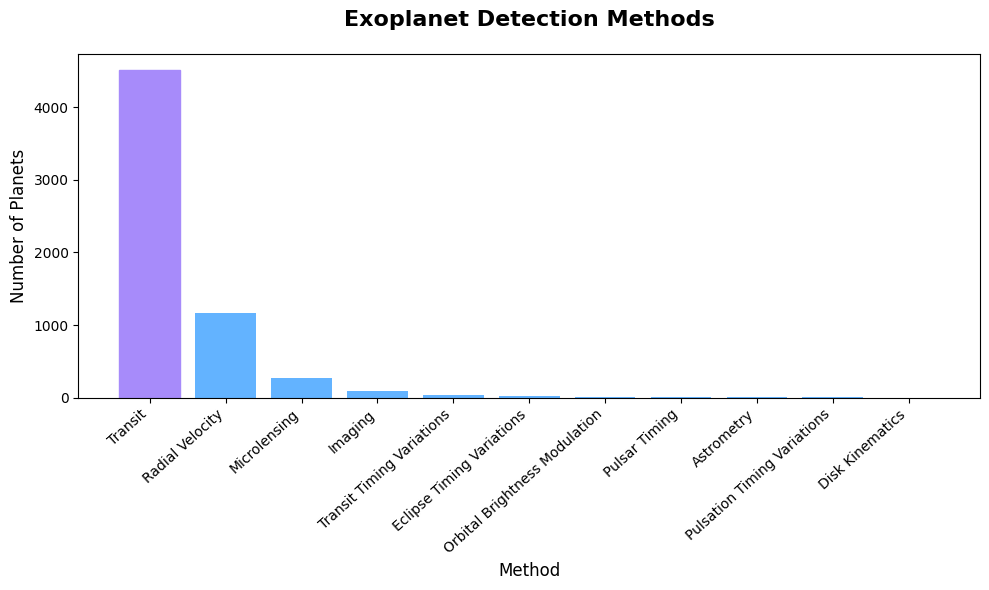

Chart saved!


In [3]:
# Bar chart : Detection methods

detection = df['discoverymethod'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(detection.index, detection.values, color='#63b3ff', edgecolor='none')

# Color the first bar differently
bars[0].set_color('#a78bfa')

plt.title('Exoplanet Detection Methods', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Number of Planets', fontsize=12)
plt.xticks(rotation=42, ha='right')
plt.tight_layout()
plt.savefig('../dashboard/detection_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

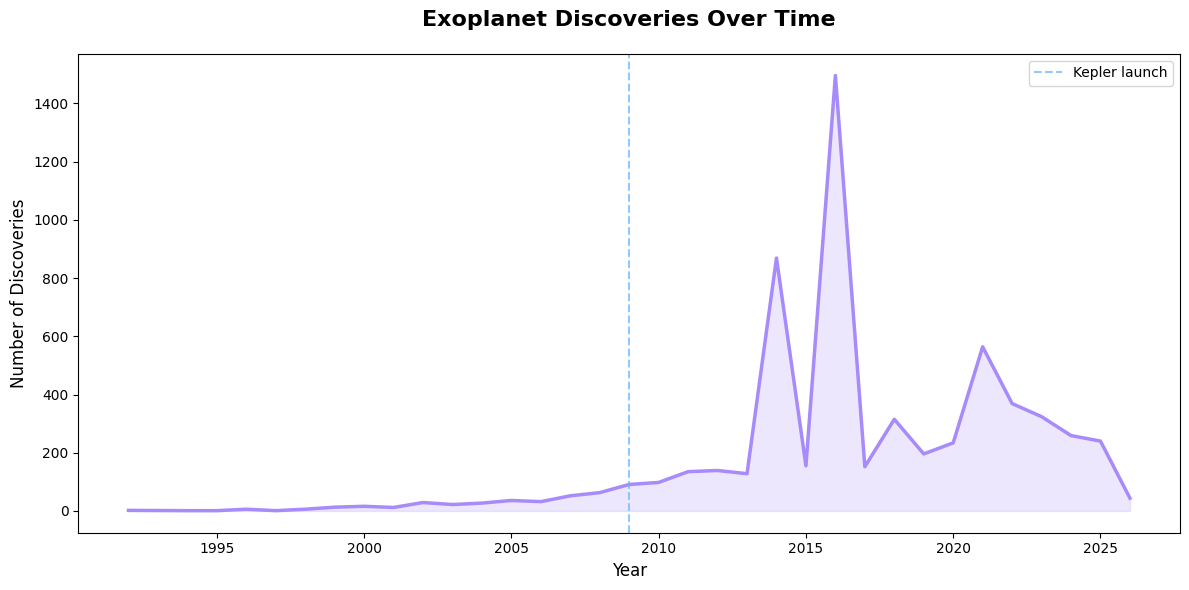

Chart saved!


In [4]:
# Line chart : Discoveries over time

discoveries = df.groupby('disc_year').size().reset_index(name='count')

plt.figure(figsize=(12, 6))
plt.plot(discoveries['disc_year'], discoveries['count'], color='#a78bfa', linewidth=2.5)
plt.fill_between(discoveries['disc_year'], discoveries['count'], alpha=0.2, color='#a78bfa')

plt.title('Exoplanet Discoveries Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Discoveries', fontsize=12)
plt.axvline(x=2009, color='#63b3ff', linestyle='--', alpha=0.7, label='Kepler launch')
plt.legend()
plt.tight_layout()
plt.savefig('../dashboard/discoveries_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")


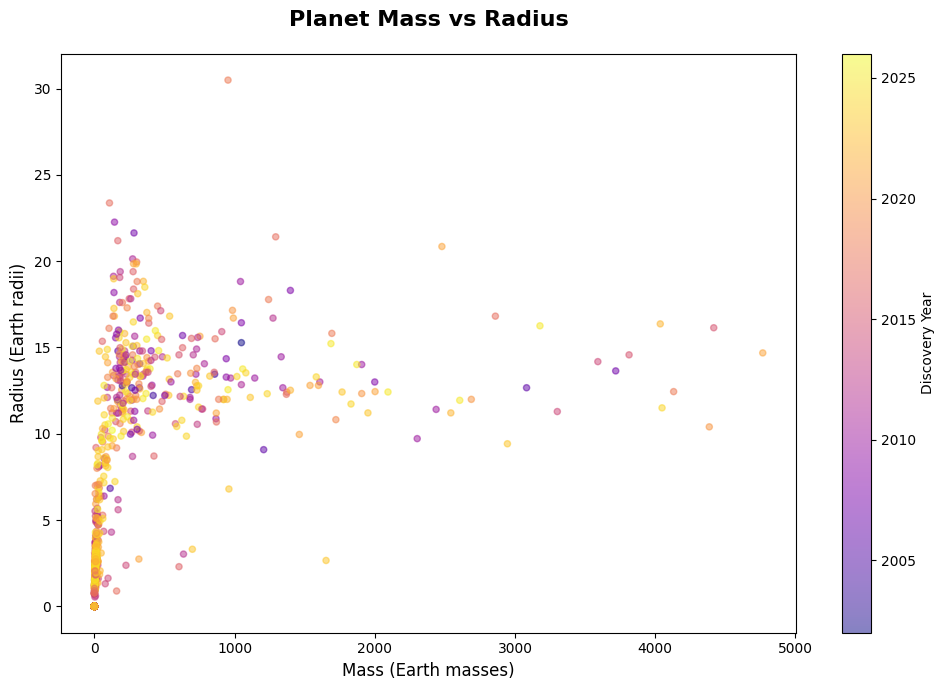

Chart saved!


In [7]:
# Scatter plot : masse vs radius

# on supprime les lignes ou la masse OU le rayon est manquant
df_clean = df.dropna(subset=['pl_bmasse', 'pl_rade'])

# on filtre les planètes avec une masse < 5000 masses terrestres
# pour éviter que Kepler-1999 b écrase tout le graphique
df_clean = df_clean[df_clean['pl_bmasse'] < 5000]

# Meme chose
df_clean = df_clean[df_clean['pl_rade'] < 50]

# on crée une figura de taille 10x7 pouces
plt.figure(figsize=(10, 7))

# on crée le scatter plot :
# axe X = masse des planètes
# axe Y = rayon des planètes
# c = couleur selon l'année de découverte (disc_year)
# cmap='plasma' = palette de couleur jaune/violet
# alpha=0.5 = transparence à 50% pour voir les superpositions
# s=20 = taille des points
scatter = plt.scatter(df_clean['pl_bmasse'], df_clean['pl_rade'],
                      c=df_clean['disc_year'], cmap='plasma', 
                      alpha=0.5, s=20)

# on ajoute une barre de couleur sur le côté pour lire l'année
plt.colorbar(scatter, label='Discovery Year')

plt.title('Planet Mass vs Radius', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mass (Earth masses)', fontsize=12)
plt.ylabel('Radius (Earth radii)', fontsize=12)
plt.tight_layout()

# on sauvegarde le graphique dans le dossier dashboard
plt.savefig('../dashboard/mass_vs_radius.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")
